In [1]:
# this code is a combination of code from the following sources:
# https://keras.io/examples/structured_data/structured_data_classification_from_scratch/ 
# https://github.com/keras-team/keras-io/blob/master/examples/structured_data/structured_data_classification_from_scratch.py
# https://keras.io/examples/structured_data/wide_deep_cross_networks/
# https://www.tensorflow.org/recommenders/examples/dcn

In [2]:
# other resources:
# https://www.tensorflow.org/guide/keras/preprocessing_layers
# "Wide & Deep "
# "Deep & Cross Network for Ad Click Predictions"       - https://arxiv.org/pdf/1708.05123.pdf

In [3]:
"""
## Setup
"""

import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
"""
## Preparing the data
Let's download the data and load it into a Pandas dataframe:
"""

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)

In [5]:
"""
The dataset includes 303 samples with 14 columns per sample (13 features, plus the target
label):
"""

dataframe.shape

(303, 14)

In [6]:
dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [7]:
# I'm only going to use a subset of the columns, to make it easier to experiment with different network architectures:

experiment_data = dataframe[['target','slope','age','sex','thal','restecg']].copy()
experiment_data = experiment_data.query("thal.isin(['normal','reversible','fixed'])", engine='python')

experiment_data['sex'] = np.select( condlist = [ experiment_data['sex'] == 0,
                                                 experiment_data['sex'] == 1
                                               ],
                                    choicelist = [ 'female', 'male' ],
                                    default = None
                                  )

experiment_data['restecg'] = 'ecg' + experiment_data['restecg'].astype(str) 

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg
302,1,2,63,female,reversible,ecg2
113,0,1,48,male,normal,ecg0
170,1,2,53,male,reversible,ecg0
74,0,2,45,female,normal,ecg2
256,0,1,61,female,normal,ecg2
120,0,2,59,female,normal,ecg0
200,0,1,51,female,normal,ecg2
300,1,2,65,male,reversible,ecg2
206,0,1,57,male,reversible,ecg0
69,0,1,35,female,normal,ecg0


In [8]:
# prepare features for model:

# normalize numeric variables:
experiment_data['slope'] = ( experiment_data['slope'] - np.mean(experiment_data['slope']) ) / np.std(experiment_data['slope'])  # normalize "slope" 
experiment_data['age'] = ( experiment_data['age'] - np.mean(experiment_data['age']) ) / np.std(experiment_data['age'])  # normalize "age" 

# create crossed features:
features_to_cross = ['sex','thal','restecg']
import itertools
for combination in itertools.combinations(features_to_cross,2):
    experiment_data[ combination[0]+'X'+combination[1] ] = experiment_data[ combination[0] ] + '_' + experiment_data[ combination[1] ]

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg,sexXthal,sexXrestecg,thalXrestecg
248,0,-0.963983,0.269044,female,normal,ecg1,female_normal,female_ecg1,normal_ecg1
154,1,0.657016,-0.506436,male,reversible,ecg2,male_reversible,male_ecg2,reversible_ecg2
234,0,2.278016,0.158261,male,normal,ecg0,male_normal,male_ecg0,normal_ecg0
227,0,-0.963983,-0.838784,male,normal,ecg0,male_normal,male_ecg0,normal_ecg0
302,1,0.657016,0.933741,female,reversible,ecg2,female_reversible,female_ecg2,reversible_ecg2
56,0,-0.963983,-1.171133,male,normal,ecg2,male_normal,male_ecg2,normal_ecg2
34,0,-0.963983,-1.171133,male,normal,ecg0,male_normal,male_ecg0,normal_ecg0
212,1,0.657016,-1.392698,male,fixed,ecg0,male_fixed,male_ecg0,fixed_ecg0
274,0,0.657016,0.379827,male,reversible,ecg2,male_reversible,male_ecg2,reversible_ecg2
196,0,-0.963983,0.822958,male,normal,ecg2,male_normal,male_ecg2,normal_ecg2


In [9]:
# train/validation/test 70%/20%/10% split: 
val_data = experiment_data.sample(frac=0.3, random_state=69420)
train_data = experiment_data.drop(val_data.index)
test_data = val_data.sample(frac=0.33, random_state=69420)
val_data = val_data.drop(test_data.index)

print(
    "Using %d samples for training, %d for validation and %d for testing"
    % (len(train_data), len(val_data), len(test_data))
)

Using 211 samples for training, 60 for validation and 30 for testing


In [10]:
# confirm that the train/validation/test sets are disjoint:

train_index = np.sort( train_data.index )
val_index = np.sort( val_data.index )
test_index = np.sort( test_data.index )

print( train_index )
print( val_index )
print( test_index )

[  2   4   5   6   7   8   9  10  13  14  15  18  19  20  23  24  25  27
  28  29  30  31  34  35  36  37  39  40  41  42  44  46  49  50  53  55
  56  57  58  59  60  61  62  64  65  66  67  68  69  70  72  73  74  75
  76  77  78  83  85  87  88  89  90  91  92  93  94  95  96  97  98  99
 101 104 105 107 108 111 112 113 114 116 117 120 121 123 124 126 127 129
 130 132 133 135 136 137 138 141 142 143 145 146 147 149 151 152 153 154
 155 157 158 159 161 162 163 164 166 167 170 172 173 174 175 177 179 180
 181 182 183 184 186 187 188 189 190 192 196 198 199 200 201 202 203 204
 207 208 209 210 211 212 213 214 216 217 218 219 220 221 222 223 224 225
 226 228 229 231 236 239 241 243 244 245 246 248 250 253 254 257 258 259
 260 261 264 265 268 269 270 271 272 273 274 278 279 281 282 283 284 285
 286 287 288 290 292 293 294 295 297 298 299 300 302]
[  0   1  11  12  21  26  32  33  43  51  52  63  79  80  82  84 100 102
 103 106 109 110 115 118 119 122 134 148 150 156 160 165 168 176 194 1

In [11]:
def dataframe_to_dataset(dataframe, shuffle=False):
    dataframe = dataframe.copy()
    labels = dataframe.pop('target')    # pull out y (response) column 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    if shuffle==True:
        ds = ds.shuffle( buffer_size=len(dataframe) )
    return ds

train_ds = dataframe_to_dataset( train_data, shuffle=True )
val_ds = dataframe_to_dataset( val_data, shuffle=True )
test_set = dataframe_to_dataset( train_data, shuffle=False )

# batch the datasets:
train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)
test_set = test_set.batch(32)

In [12]:
def create_model_inputs():
    inputs = {}
    for feature_name in FEATURE_NAMES:
        if feature_name in NUMERIC_FEATURE_NAMES:
            inputs[feature_name] = layers.Input(
                name=feature_name, shape=(), dtype=tf.float32
            )
        else:
            inputs[feature_name] = layers.Input(
                name=feature_name, shape=(), dtype=tf.string
            )
    return inputs

In [13]:
NUMERIC_FEATURE_NAMES = [
    'slope',
    'age'
]

CATEGORICAL_FEATURES_WITH_VOCABULARY = {
    # format is 'feature_name': [list of unique feature values]
    'sex': list( experiment_data['sex'].unique() ),
    'thal': list( experiment_data['thal'].unique() ),
    'restecg': list( experiment_data['restecg'].unique() ),
    'sexXthal': list( experiment_data['sexXthal'].unique() ),
    'sexXrestecg': list( experiment_data['sexXrestecg'].unique() ),
    'thalXrestecg': list( experiment_data['thalXrestecg'].unique() )
}

FEATURES_WITH_EMBEDDING_DIMENSION = {           
    # format is 'feature_name': desired embedding dimension
    'thal': 2,
    'thalXrestecg': 3
}

CATEGORICAL_FEATURE_NAMES = list( CATEGORICAL_FEATURES_WITH_VOCABULARY.keys() )
TO_EMBED_FEATURE_NAMES = list( FEATURES_WITH_EMBEDDING_DIMENSION.keys() )

FEATURE_NAMES = NUMERIC_FEATURE_NAMES + CATEGORICAL_FEATURE_NAMES

In [14]:
from tensorflow.keras.layers.experimental.preprocessing import CategoryEncoding
from tensorflow.keras.layers.experimental.preprocessing import StringLookup

def encode_inputs( inputs, input_layer_name=None ):
    encoded_features = []
    for feature_name in inputs:
        if feature_name in CATEGORICAL_FEATURE_NAMES:
            vocabulary = CATEGORICAL_FEATURES_WITH_VOCABULARY[feature_name]
            # Create a lookup to convert string values to an integer index.
            # Since we are not using a mask token nor expecting any out of vocabulary
            # (oov) token, we set mask_token to None and  num_oov_indices to 0.
            index = StringLookup(
                    vocabulary = vocabulary, 
                    mask_token = None, 
                    num_oov_indices = 0
            )
            # Convert the string input values into integer indices.
            value_index = index( inputs[feature_name] )
            if feature_name in TO_EMBED_FEATURE_NAMES:
                embedding_dim = int( FEATURES_WITH_EMBEDDING_DIMENSION[feature_name] )
                # Create an embedding layer with the specified dimensions.
                embedding_encoder = layers.Embedding(
                    input_dim = len(vocabulary),
                    output_dim = embedding_dim
                )
                # Convert the index values to embedding representations.
                encoded_feature = embedding_encoder(value_index)
            else:
                # Create a one-hot encoder.
                onehot_encoder = CategoryEncoding(output_mode="binary")
                onehot_encoder.adapt( index(vocabulary) )
                # Convert the index values to a one-hot representation.
                encoded_feature = onehot_encoder(value_index)
        else:
            # Use the numerical features as-is.
            encoded_feature = tf.expand_dims(inputs[feature_name], -1)

        encoded_features.append(encoded_feature)
    
    if input_layer_name is not None:
        all_features = layers.concatenate( encoded_features, name=input_layer_name )
    else:
        all_features = layers.concatenate( encoded_features )
    return all_features

In [15]:
inputs = create_model_inputs()
input_features = encode_inputs( inputs, input_layer_name='all_features' )

# Standard Dense Neural Network (DNN)

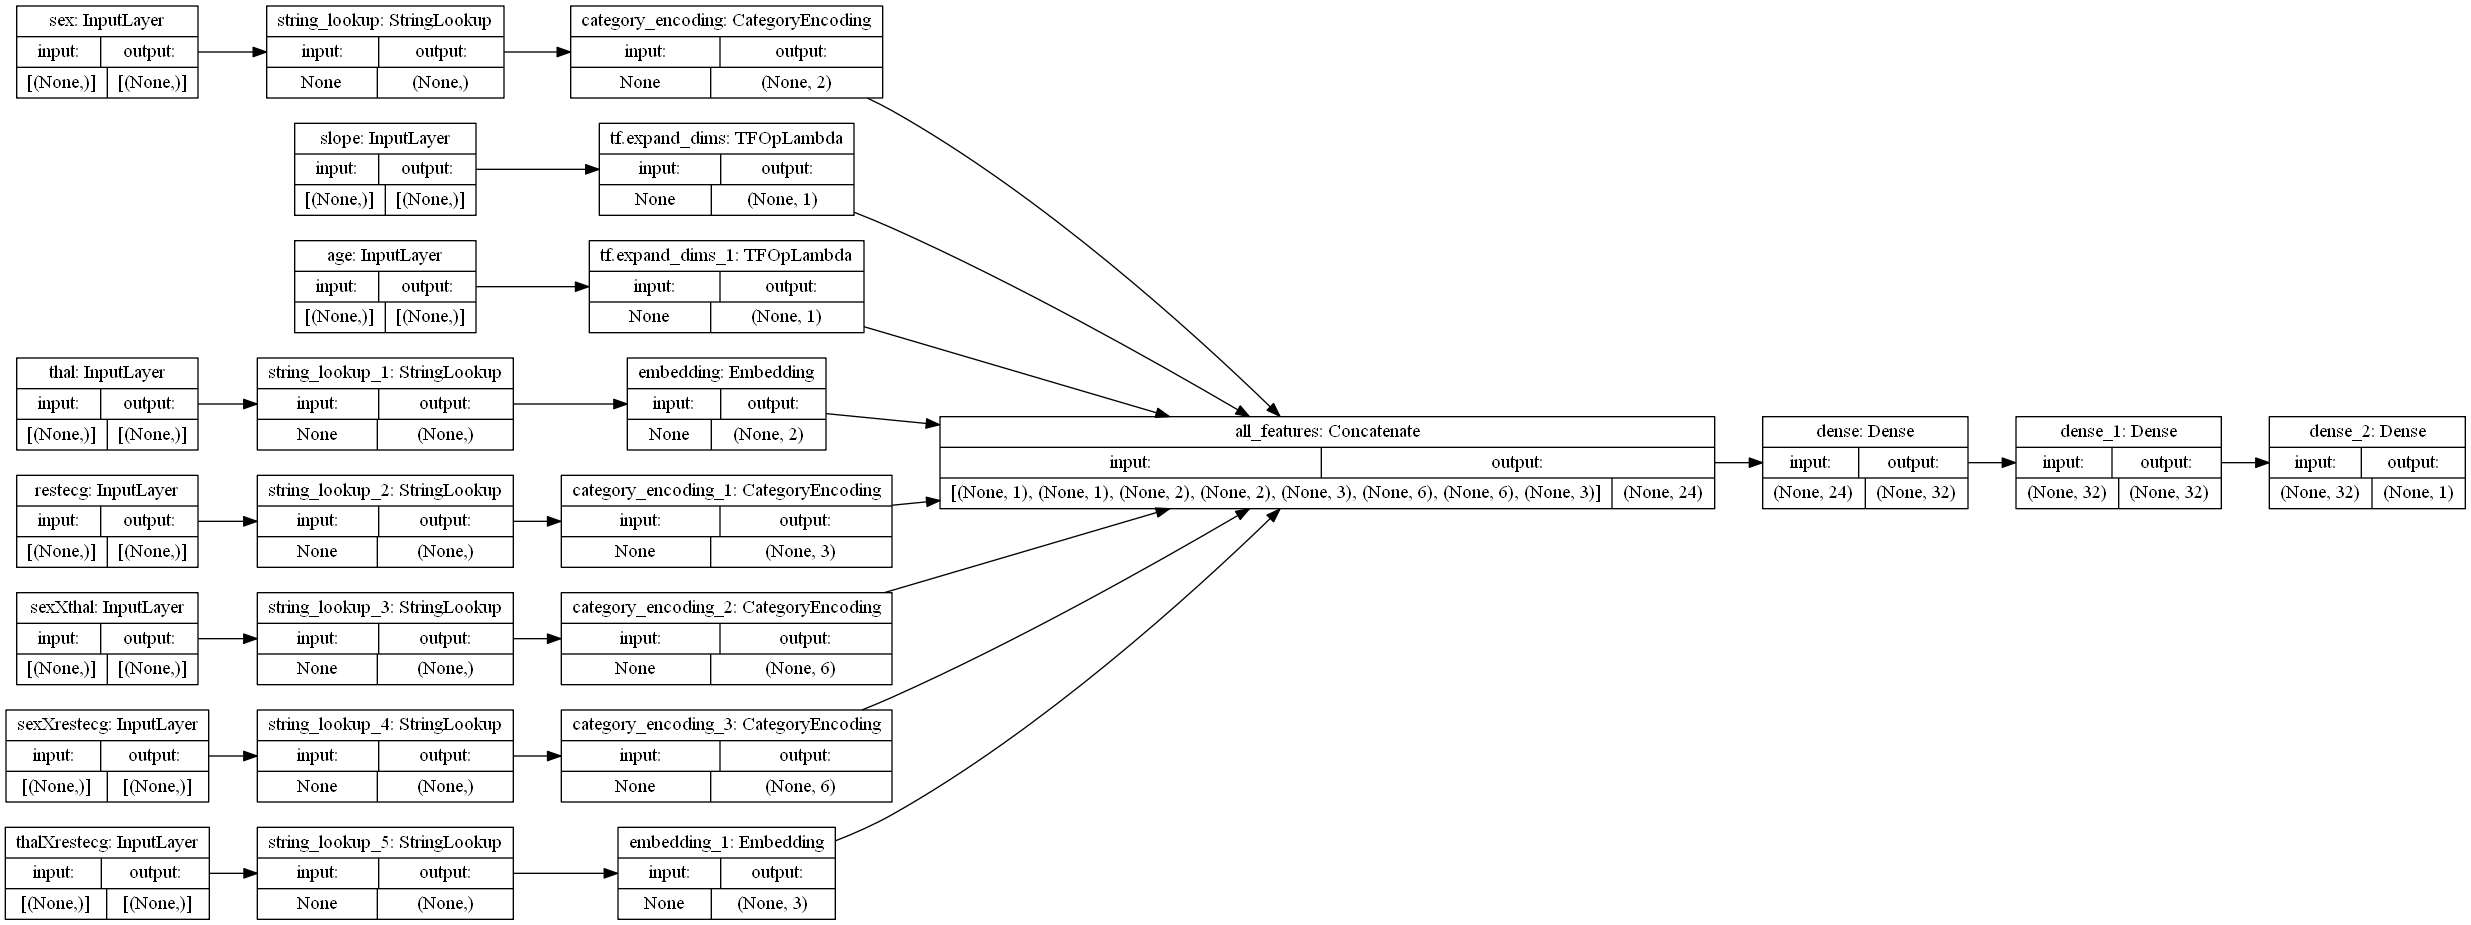

In [16]:
deep_layer1 = layers.Dense(32)(input_features)
deep_layer2 = layers.Dense(32)(deep_layer1)
deep_output = layers.Dense(1, activation="sigmoid")(deep_layer2)
model = keras.Model(inputs=inputs, outputs=deep_output)

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [17]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
sex (InputLayer)                [(None,)]            0                                            
__________________________________________________________________________________________________
thal (InputLayer)               [(None,)]            0                                            
__________________________________________________________________________________________________
restecg (InputLayer)            [(None,)]            0                                            
__________________________________________________________________________________________________
sexXthal (InputLayer)           [(None,)]            0                                            
______________________________________________________________________________________________

In [18]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

In [19]:
model.fit( train_ds,
           epochs = 20,
           validation_data = val_ds
         )

Epoch 1/20
7/7 [==============================] - 3s 180ms/step - loss: 0.6816 - accuracy: 0.5232 - val_loss: 0.6774 - val_accuracy: 0.7000
Epoch 2/20
7/7 [==============================] - 0s 12ms/step - loss: 0.6030 - accuracy: 0.7264 - val_loss: 0.6187 - val_accuracy: 0.7000
Epoch 3/20
7/7 [==============================] - 0s 13ms/step - loss: 0.5431 - accuracy: 0.7401 - val_loss: 0.5815 - val_accuracy: 0.7167
Epoch 4/20
7/7 [==============================] - 0s 14ms/step - loss: 0.4805 - accuracy: 0.7555 - val_loss: 0.5561 - val_accuracy: 0.6833
Epoch 5/20
7/7 [==============================] - 0s 14ms/step - loss: 0.4262 - accuracy: 0.7914 - val_loss: 0.5419 - val_accuracy: 0.6833
Epoch 6/20
7/7 [==============================] - 0s 16ms/step - loss: 0.4226 - accuracy: 0.7632 - val_loss: 0.5319 - val_accuracy: 0.7167
Epoch 7/20
7/7 [==============================] - 0s 17ms/step - loss: 0.4181 - accuracy: 0.7837 - val_loss: 0.5280 - val_accuracy: 0.6833
Epoch 8/20
7/7 [==========

In [20]:
# final model performance on validation set 
model.evaluate( val_ds )

2/2 [==============================] - 0s 6ms/step - loss: 0.5318 - accuracy: 0.6833


[0.5317500829696655, 0.6833333373069763]

In [21]:
# final model performance on test set 
model.evaluate( test_set )

7/7 [==============================] - 0s 4ms/step - loss: 0.3694 - accuracy: 0.8152


[0.3694101870059967, 0.8151658773422241]

In [22]:
# final model predictions on test set 
model.predict( test_set )

array([[0.7133302 ],
       [0.02236533],
       [0.04602584],
       [0.47731134],
       [0.00854778],
       [0.68877256],
       [0.8846279 ],
       [0.45446783],
       [0.19114697],
       [0.2300336 ],
       [0.04732984],
       [0.00657904],
       [0.03781205],
       [0.24874994],
       [0.29155797],
       [0.66962004],
       [0.03158537],
       [0.19491613],
       [0.03190953],
       [0.5300474 ],
       [0.01210663],
       [0.27414992],
       [0.03282741],
       [0.03101653],
       [0.5518762 ],
       [0.41026136],
       [0.20599836],
       [0.84142613],
       [0.01078182],
       [0.68290645],
       [0.15921038],
       [0.04418147],
       [0.17161894],
       [0.29155797],
       [0.03312951],
       [0.04114407],
       [0.0381583 ],
       [0.04151946],
       [0.03149438],
       [0.02975479],
       [0.25986364],
       [0.957574  ],
       [0.6503614 ],
       [0.04177129],
       [0.2300336 ],
       [0.5368644 ],
       [0.34264246],
       [0.056

# Wide & Deep Network

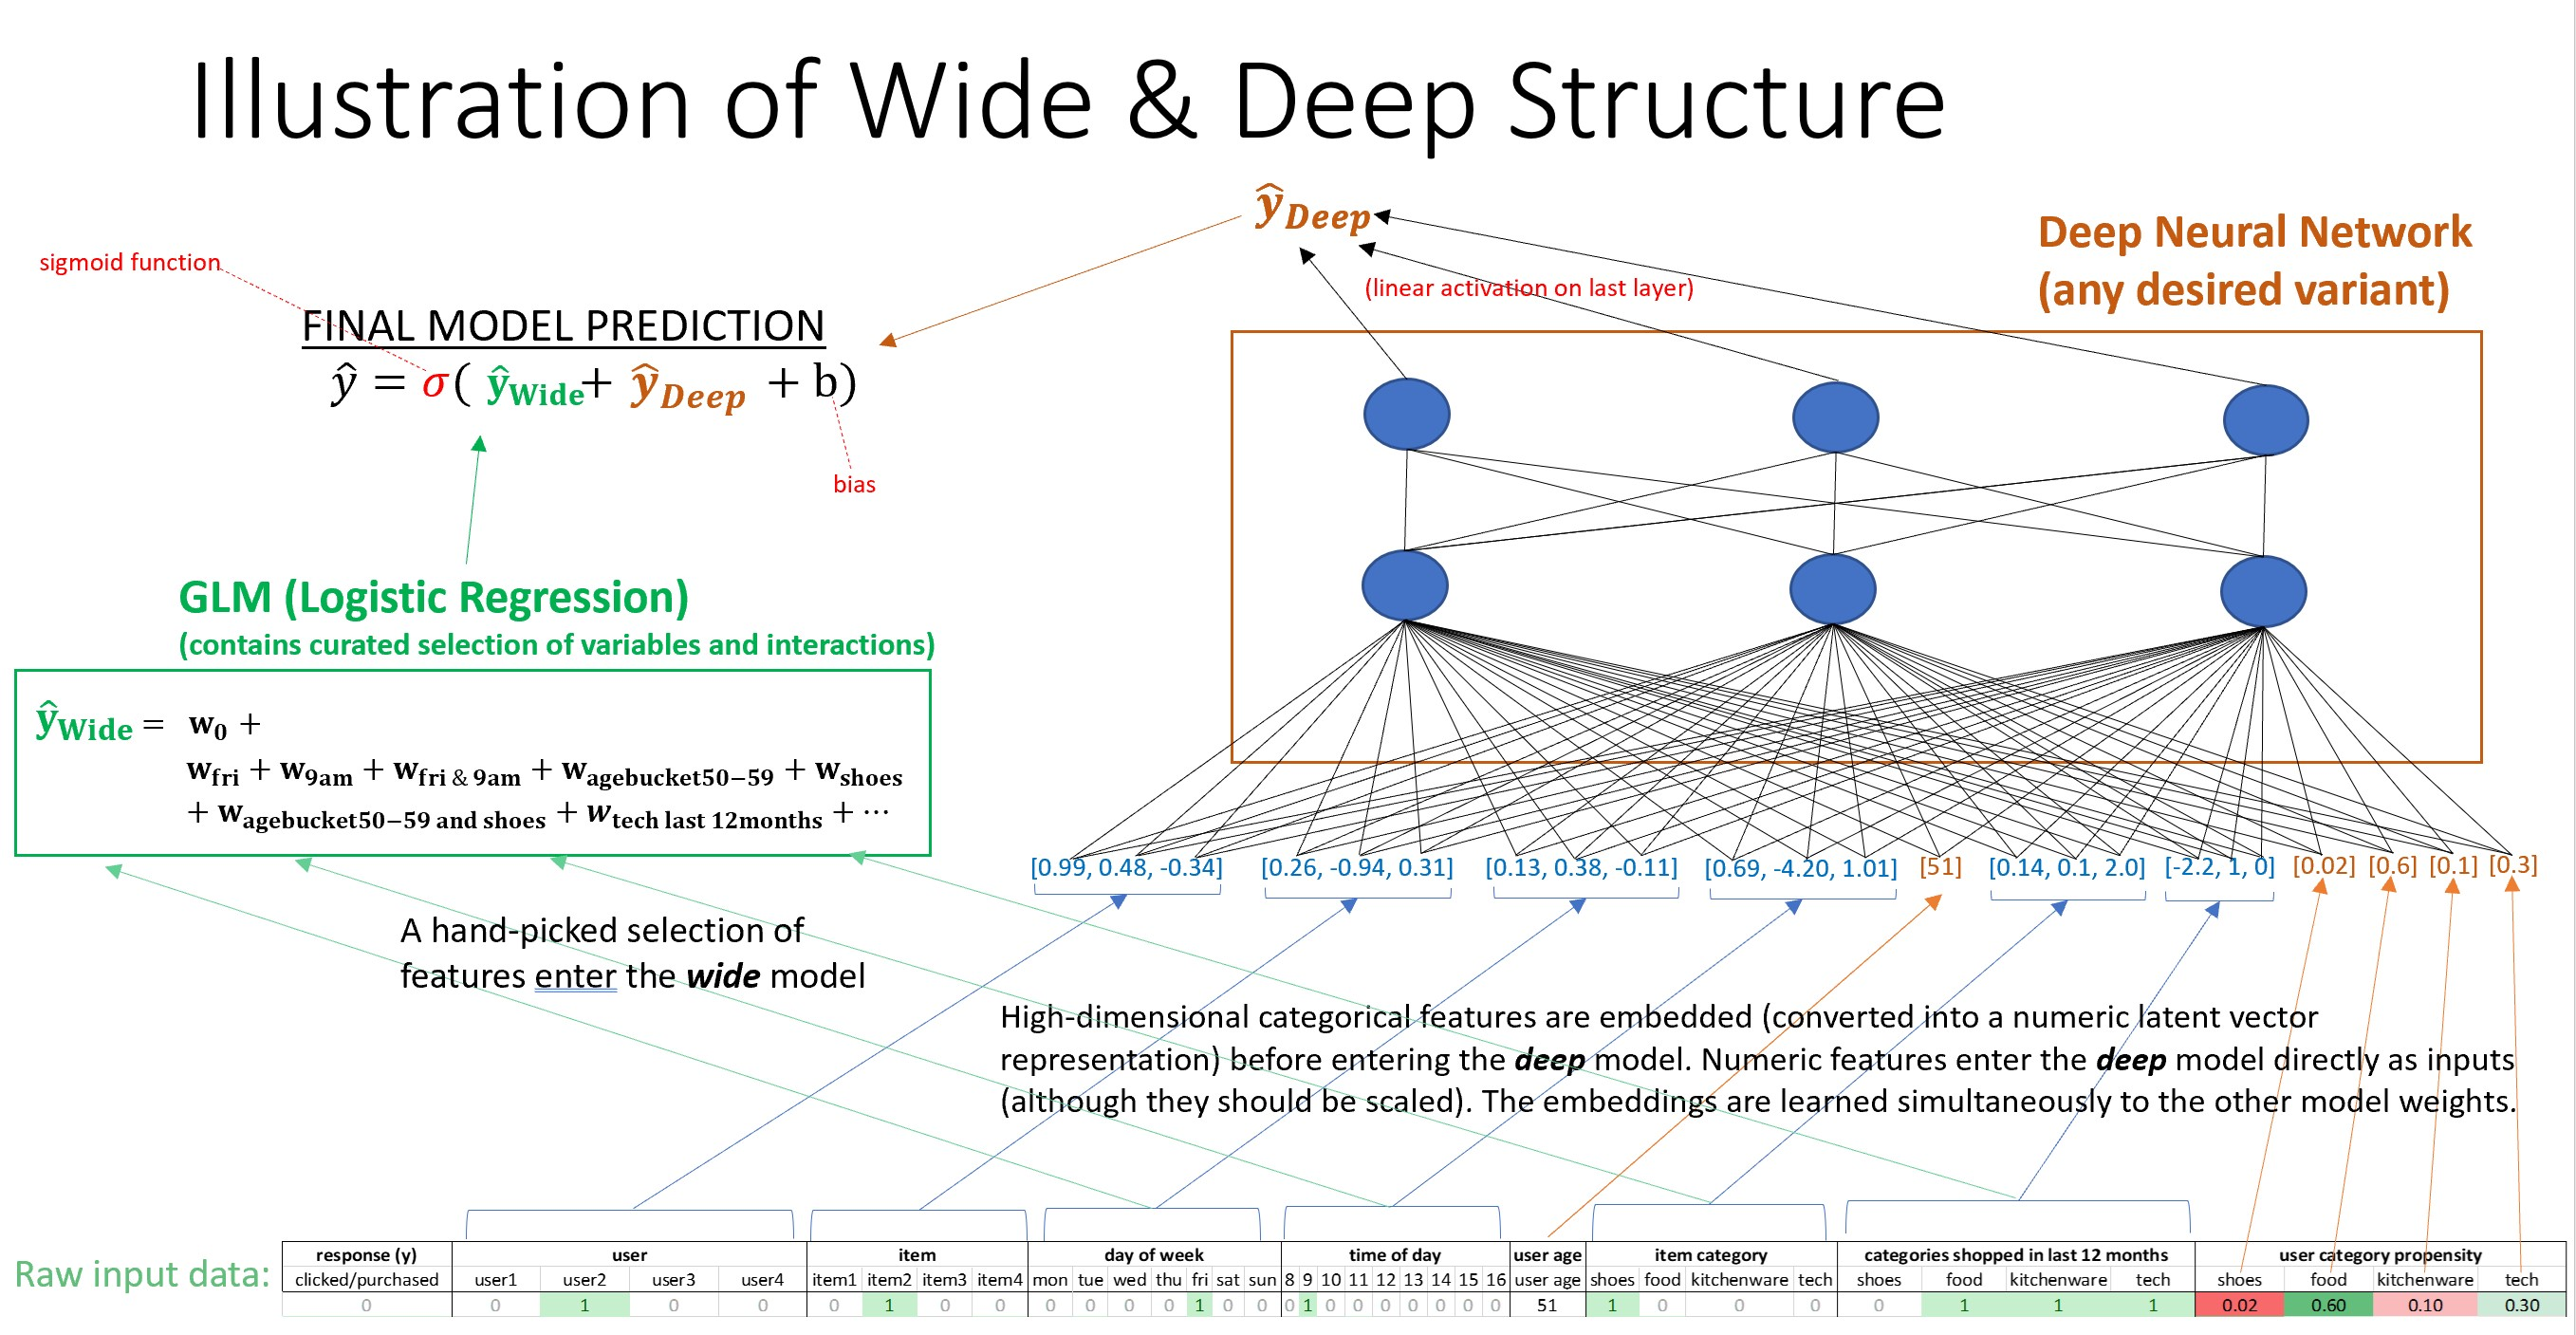

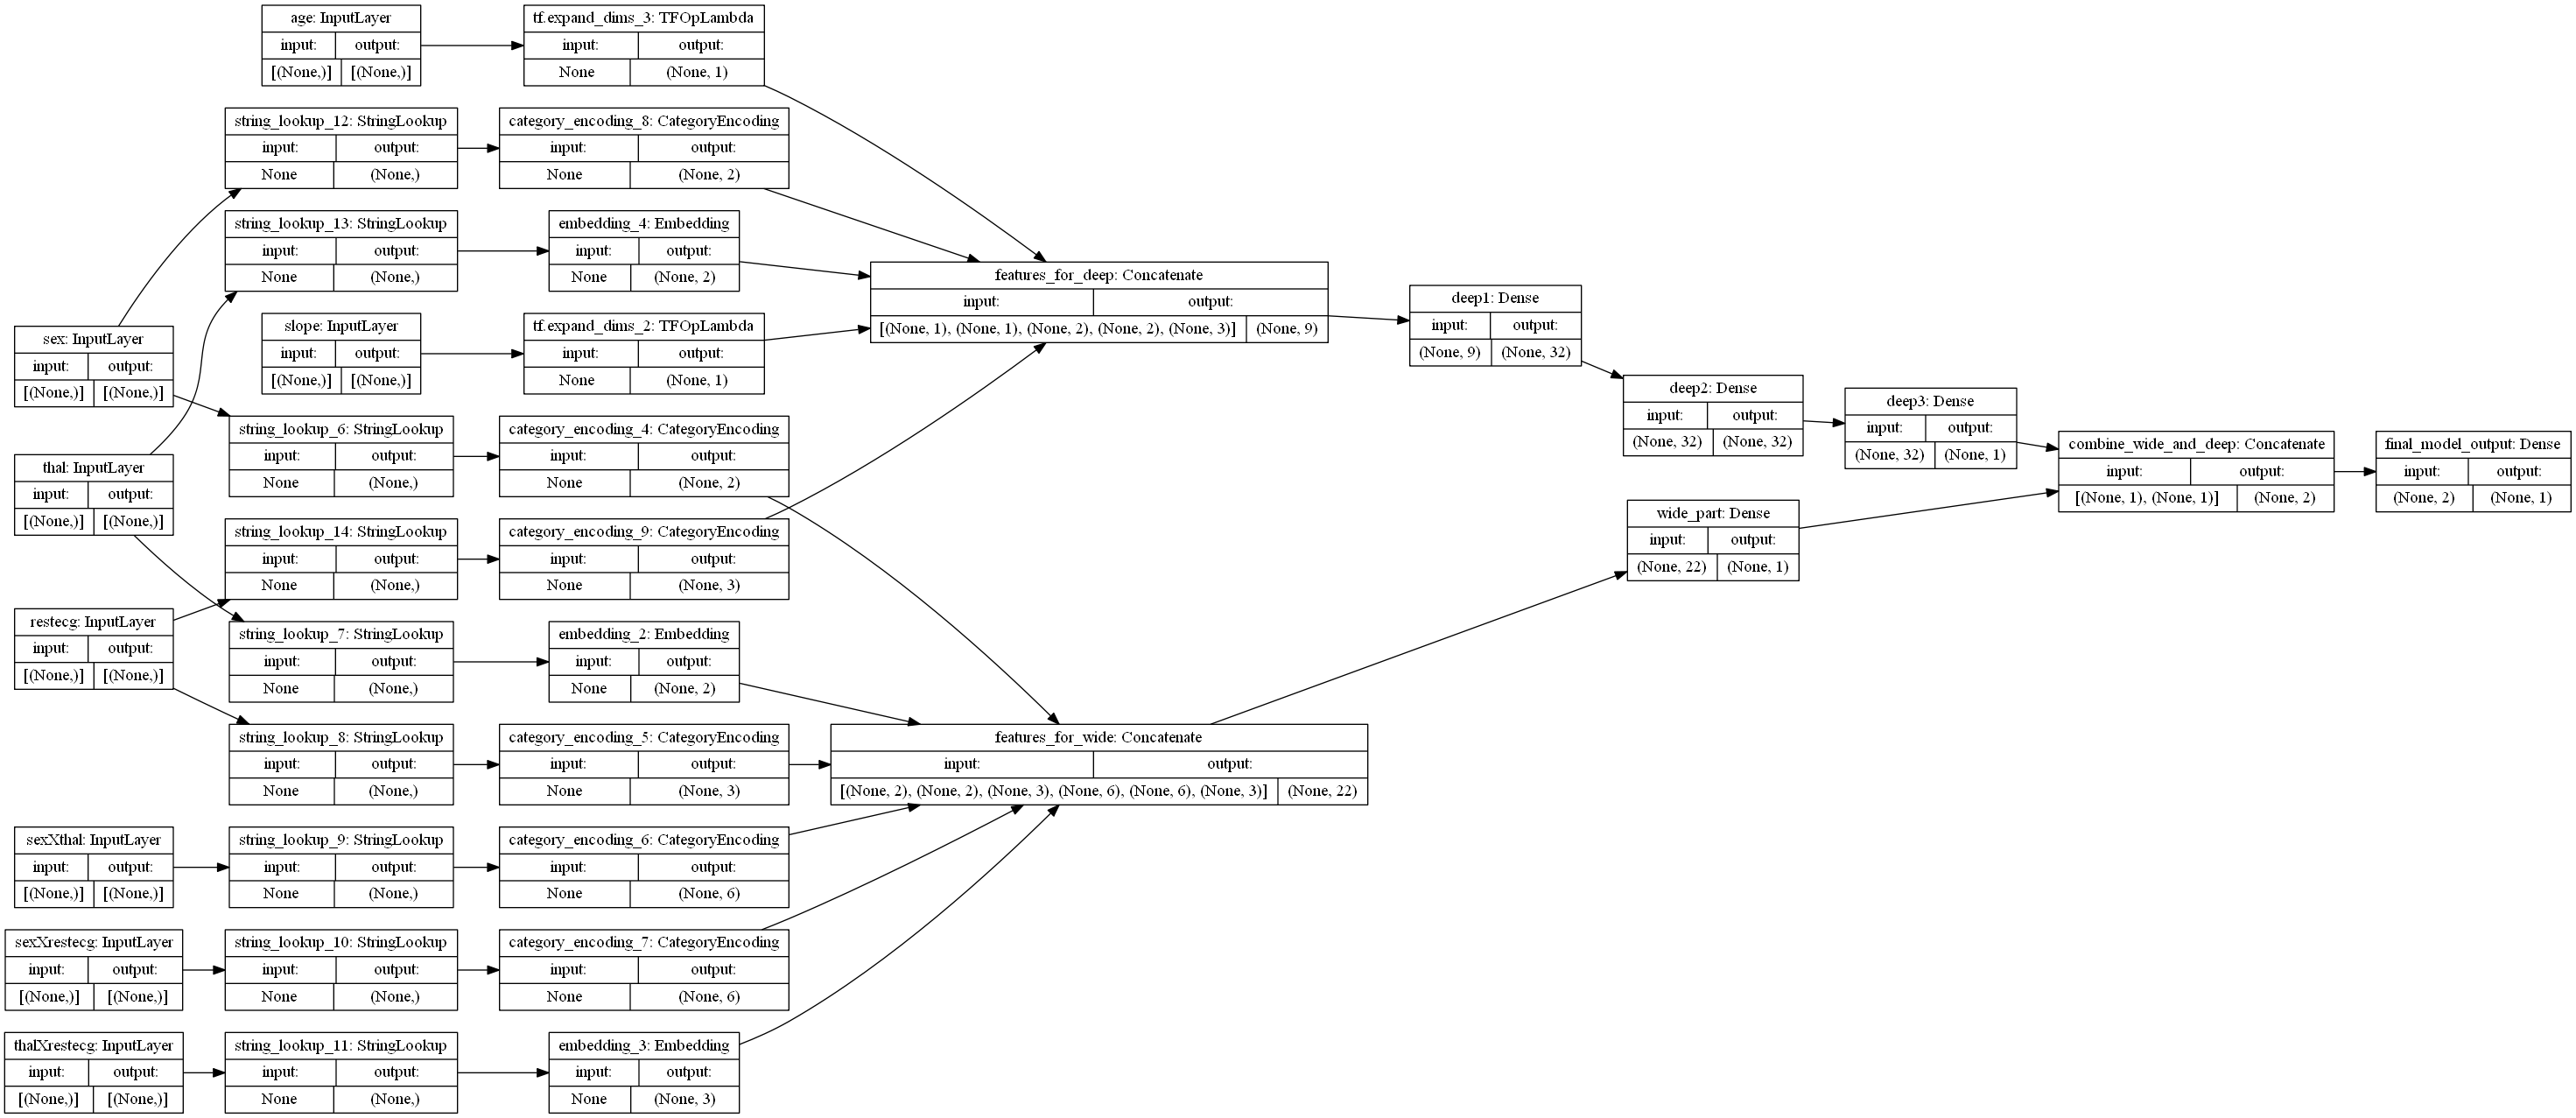

In [23]:
wide_inputs = { x: inputs[x] for x in ['sex','thal','restecg','sexXthal','sexXrestecg','thalXrestecg'] }
deep_inputs = { x: inputs[x] for x in ['slope','age','sex','thal','restecg'] }
input_features_for_wide = encode_inputs( wide_inputs, input_layer_name='features_for_wide' )
input_features_for_deep =  encode_inputs( deep_inputs, input_layer_name='features_for_deep' )

wide_output = layers.Dense(1, 
                           activation='linear',
                           name = 'wide_part',
                          )(input_features_for_wide)

deep_layer1 = layers.Dense( 32, 
                            activation='relu',
                            name = 'deep1' 
                          )(input_features_for_deep)
deep_layer2 = layers.Dense( 32, 
                            activation='relu',
                            name = 'deep2'
                          )(deep_layer1)
deep_output = layers.Dense( 1, 
                            activation='linear',
                            name = 'deep3'
                          )(deep_layer2)

combine_model_outputs = layers.concatenate( 
    [ 
        wide_output,
        deep_output,
    ],
    name = 'combine_wide_and_deep'
)

final_output = layers.Dense( 1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(combine_model_outputs)

model = keras.Model(inputs, final_output)
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [24]:
#model.summary()

In [25]:
model.compile('adam', 'binary_crossentropy', metrics=['accuracy'])

model.fit( train_ds,
           epochs = 20,
           validation_data = val_ds
         )

Epoch 1/20
7/7 [==============================] - 3s 130ms/step - loss: 0.7295 - accuracy: 0.3966 - val_loss: 0.6835 - val_accuracy: 0.6167
Epoch 2/20
7/7 [==============================] - 0s 16ms/step - loss: 0.6867 - accuracy: 0.5745 - val_loss: 0.6616 - val_accuracy: 0.7000
Epoch 3/20
7/7 [==============================] - 0s 16ms/step - loss: 0.6511 - accuracy: 0.7278 - val_loss: 0.6427 - val_accuracy: 0.6833
Epoch 4/20
7/7 [==============================] - 0s 13ms/step - loss: 0.6318 - accuracy: 0.7399 - val_loss: 0.6273 - val_accuracy: 0.7000
Epoch 5/20
7/7 [==============================] - 0s 13ms/step - loss: 0.5992 - accuracy: 0.7435 - val_loss: 0.6143 - val_accuracy: 0.7000
Epoch 6/20
7/7 [==============================] - 0s 12ms/step - loss: 0.5664 - accuracy: 0.7704 - val_loss: 0.6023 - val_accuracy: 0.7000
Epoch 7/20
7/7 [==============================] - 0s 13ms/step - loss: 0.5696 - accuracy: 0.7293 - val_loss: 0.5905 - val_accuracy: 0.7000
Epoch 8/20
7/7 [==========

In [26]:
# final model performance on validation set 
model.evaluate( val_ds )

2/2 [==============================] - 0s 5ms/step - loss: 0.5194 - accuracy: 0.7333


[0.519437849521637, 0.7333333492279053]

In [27]:
# final model performance on test set 
model.evaluate( test_set )

7/7 [==============================] - 0s 4ms/step - loss: 0.3999 - accuracy: 0.7820


[0.3999301493167877, 0.7819905281066895]


# Deep & Cross Network

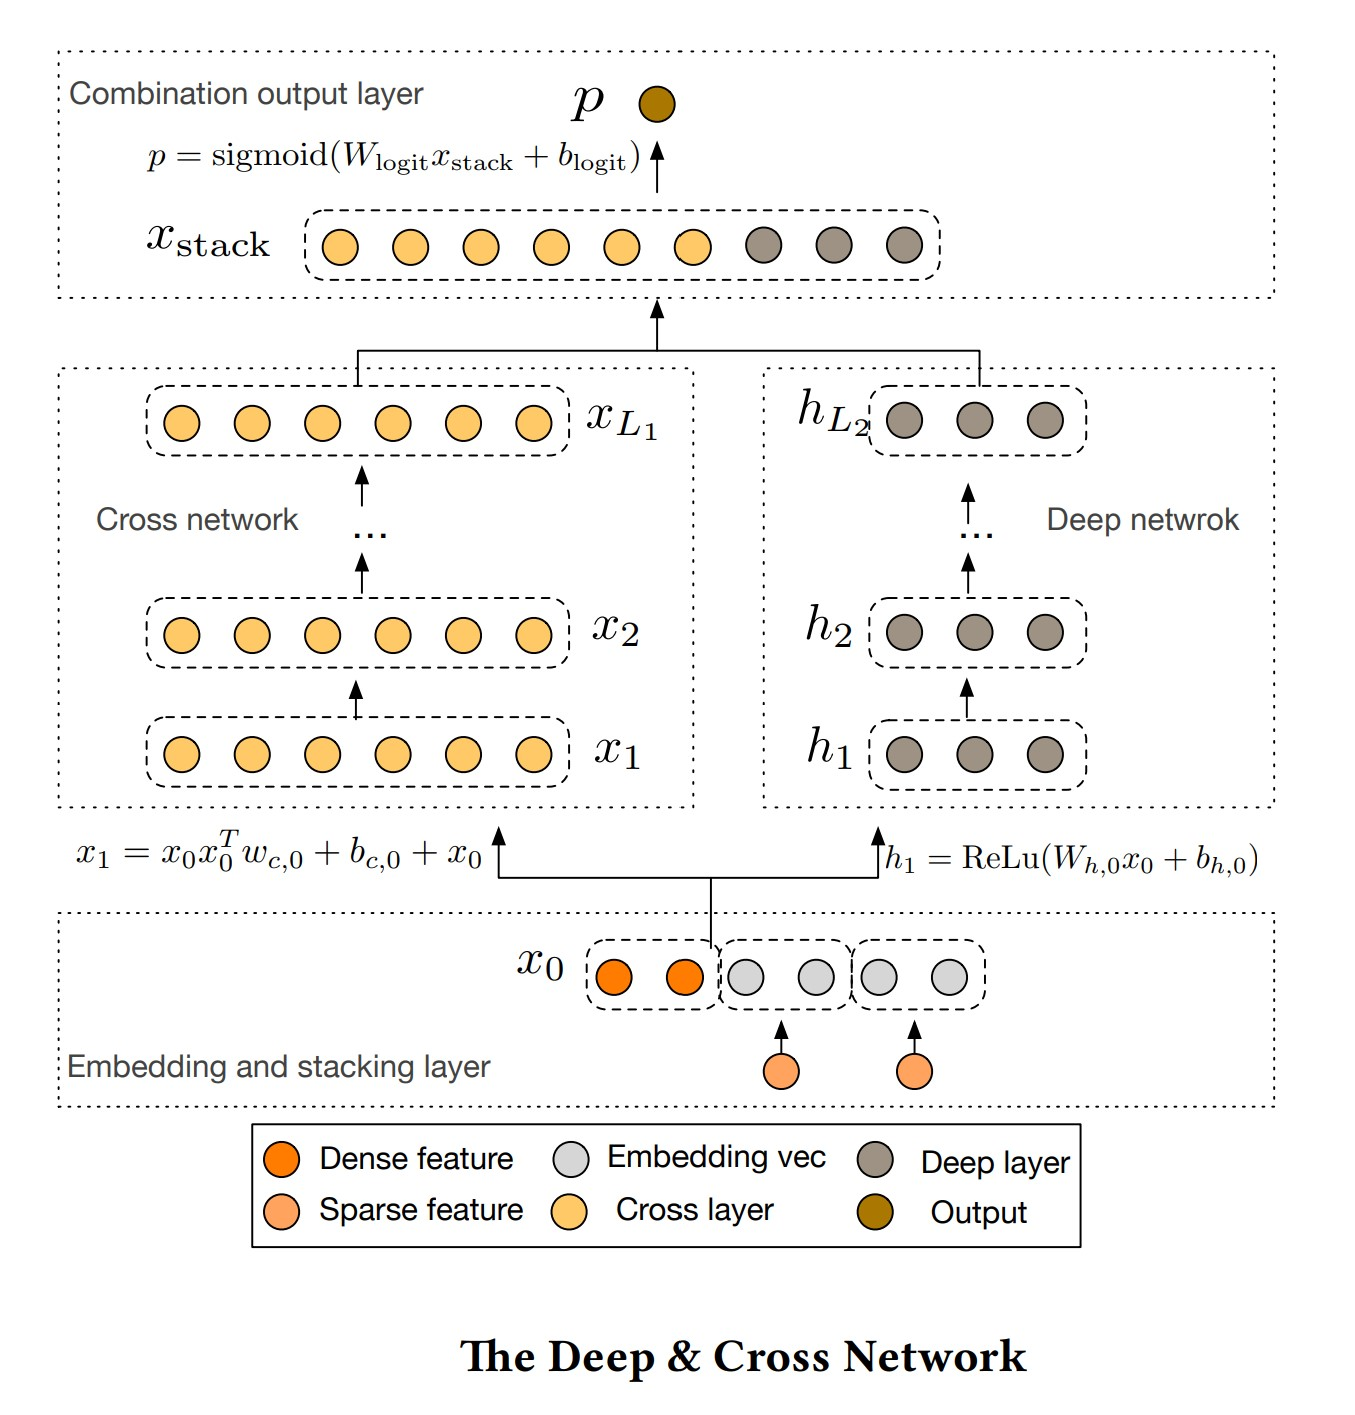

image from https://arxiv.org/pdf/1708.05123.pdf

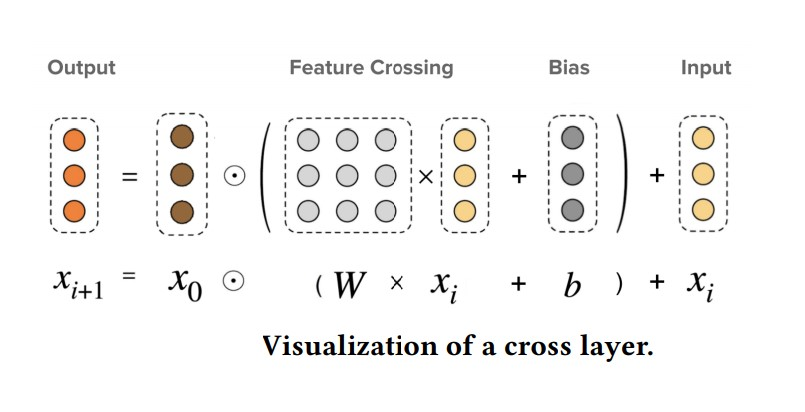

image from https://arxiv.org/pdf/2008.13535.pdf

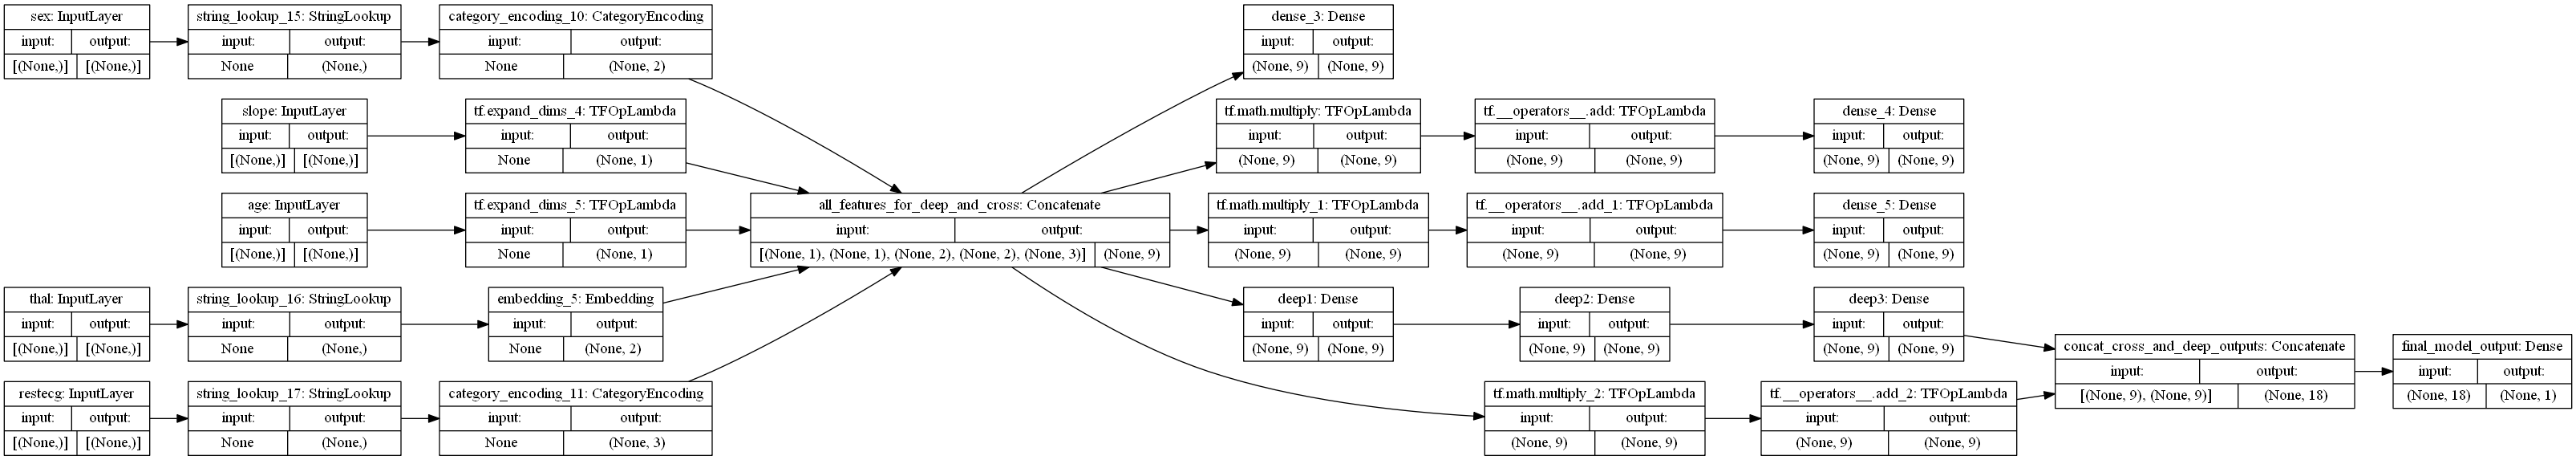

In [28]:
#################################
# Parallel Deep & Cross Network #
#################################
inputs_for_deep_and_cross = { x: inputs[x] for x in ['slope','age','sex','thal','restecg'] }

# x0 is the input layer:
x0 = encode_inputs( 
                    inputs_for_deep_and_cross, 
                    input_layer_name='all_features_for_deep_and_cross'
                  )

# cross part ---------------------------------------
x1 = x0 * layers.Dense(x0.shape[-1])(x0) + x0
x2 = x0 * layers.Dense(x1.shape[-1])(x1) + x1
x3 = x0 * layers.Dense(x2.shape[-1])(x2) + x2
cross_output = x3 

# deep part ----------------------------------------
deep_layer1 = layers.Dense( 9, 
                            activation='relu',
                            name = 'deep1' 
                          )(x0)
deep_layer2 = layers.Dense( 9, 
                            activation='relu',
                            name = 'deep2'
                          )(deep_layer1)
deep_output = layers.Dense( 9, 
                            activation='sigmoid',
                            name = 'deep3'
                          )(deep_layer2)

combine_model_outputs = layers.concatenate( 
    [ 
        cross_output,
        deep_output,
    ],
    name = 'concat_cross_and_deep_outputs'
)

final_output = layers.Dense( 1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(combine_model_outputs)

model = keras.Model( 
                     inputs_for_deep_and_cross,
                     final_output
                   )

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [29]:
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

model.fit( train_ds,
           epochs = 20,
           validation_data = val_ds
         )

Epoch 1/20


C:\Program Files (x86)\Microsoft Visual Studio\Shared\Python37_64\lib\site-packages\tensorflow\python\keras\engine\functional.py:595: UserWarning: Input dict contained keys ['sexXthal', 'sexXrestecg', 'thalXrestecg'] which did not match any model input. They will be ignored by the model.
  [n for n in tensors.keys() if n not in ref_input_names])


7/7 [==============================] - 1s 56ms/step - loss: 0.8105 - accuracy: 0.5531 - val_loss: 0.7967 - val_accuracy: 0.5167
Epoch 2/20
7/7 [==============================] - 0s 12ms/step - loss: 0.7923 - accuracy: 0.5687 - val_loss: 0.7702 - val_accuracy: 0.5167
Epoch 3/20
7/7 [==============================] - 0s 13ms/step - loss: 0.7559 - accuracy: 0.5522 - val_loss: 0.7469 - val_accuracy: 0.5500
Epoch 4/20
7/7 [==============================] - 0s 12ms/step - loss: 0.7052 - accuracy: 0.6004 - val_loss: 0.7251 - val_accuracy: 0.5500
Epoch 5/20
7/7 [==============================] - 0s 13ms/step - loss: 0.6898 - accuracy: 0.6031 - val_loss: 0.7058 - val_accuracy: 0.5500
Epoch 6/20
7/7 [==============================] - 0s 13ms/step - loss: 0.6625 - accuracy: 0.6042 - val_loss: 0.6885 - val_accuracy: 0.5667
Epoch 7/20
7/7 [==============================] - 0s 13ms/step - loss: 0.6110 - accuracy: 0.6364 - val_loss: 0.6722 - val_accuracy: 0.5667
Epoch 8/20
7/7 [======================